In [ ]:
#
# Project:
#      PyTorch Dojo (https://github.com/wo3kie/ml-dojo)
#
# Author:
#      Lukasz Czerwinski (https://www.lukaszczerwinski.pl/)
#

In [ ]:
import torch
from torchvision import datasets, transforms

import import_ipynb
from common import assert_eq # type: ignore
from log_reg_NC_sgd_gradient import logistic_regression_nc_sgd_gradient as logistic_regression_nc # type: ignore

from matplotlib import pyplot as plt

from math import log2

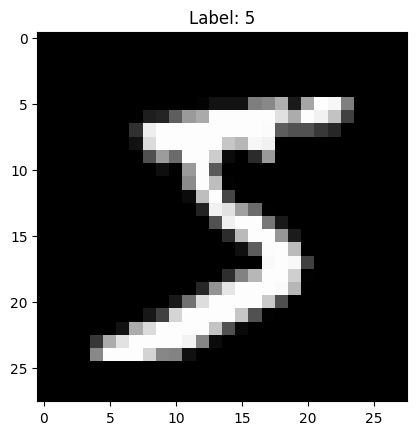

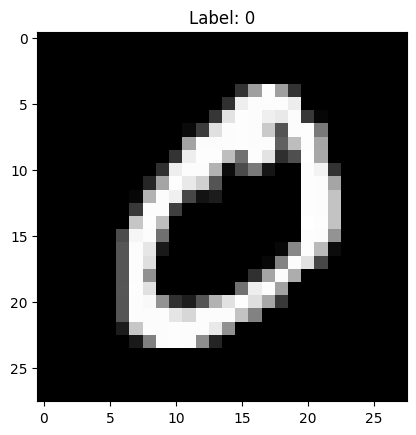

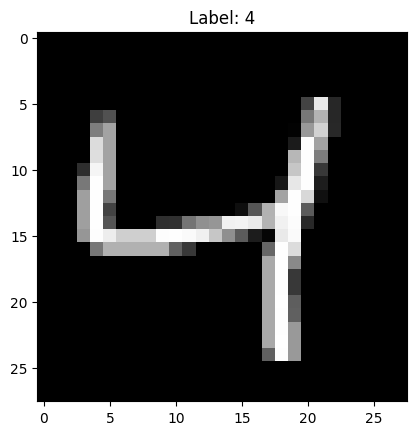

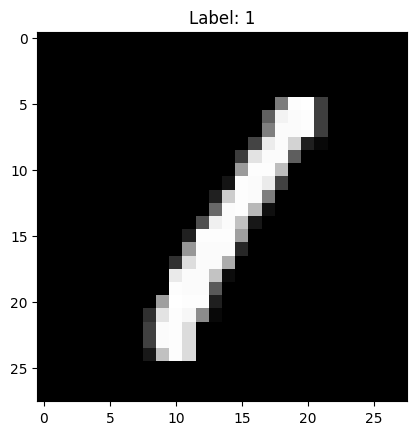

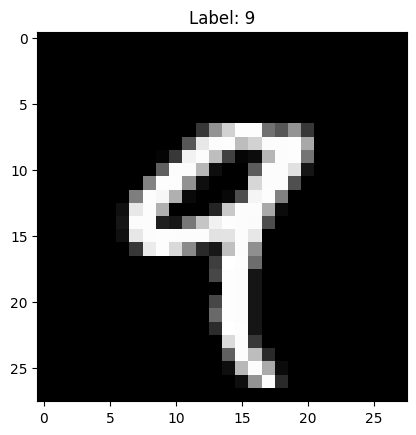

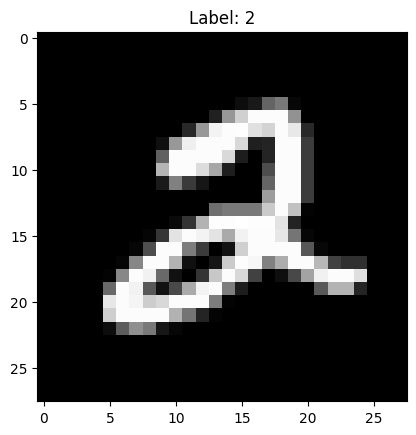

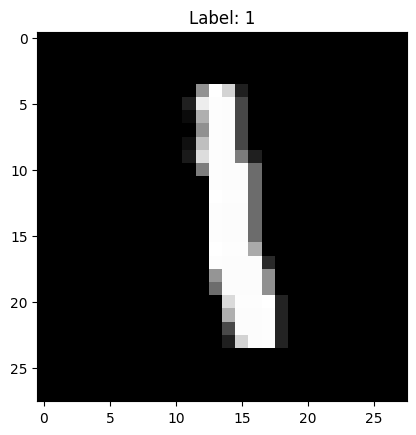

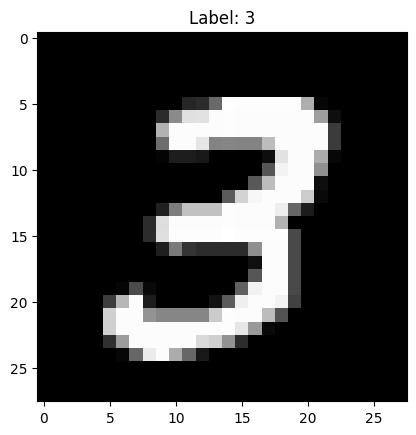

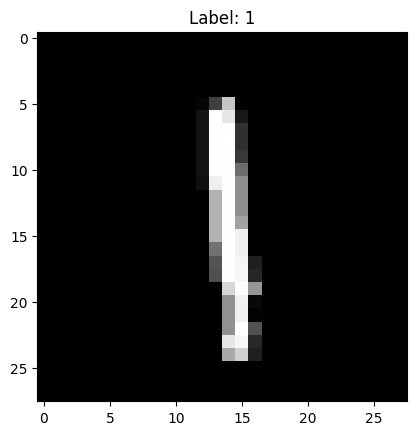

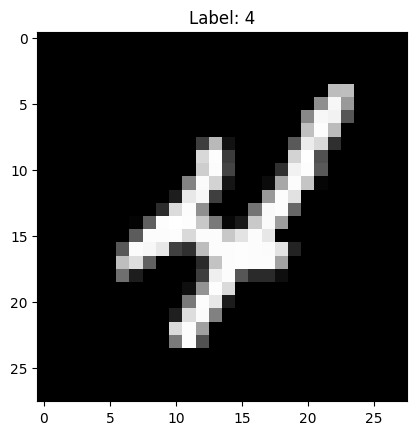

In [ ]:
#
# Load the dataset and show the first 10 samples.
#

to_tensor = transforms.ToTensor()
dataset = datasets.MNIST(root='data', train=True, download=True, transform=to_tensor)

for i in range(10):
  plt.imshow(dataset.data[i], cmap='gray')
  plt.title(f'Label: {dataset.targets[i]}')
  plt.show()

In [ ]:
#
# Train model
#
S=10000

samples_train = dataset.data[:S].float() / 255.0
samples_train = torch.reshape(samples_train, (samples_train.shape[0], -1))

labels_train = dataset.targets[:S]
labels_train = torch.reshape(labels_train, (-1, 1))

(_, model_W, _) = logistic_regression_nc(samples_train, labels_train, epochs=1000, lr=0.01)
assert_eq(model_W.T.shape, (10, 28*28))

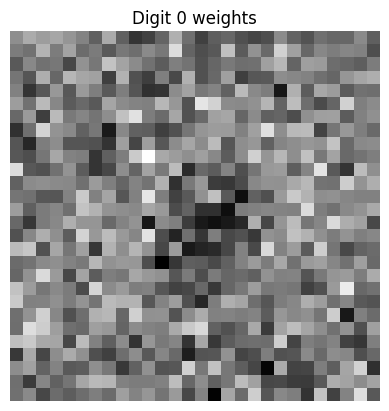

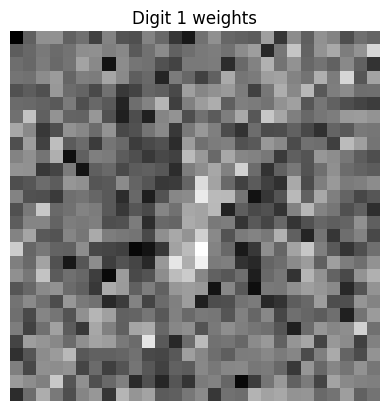

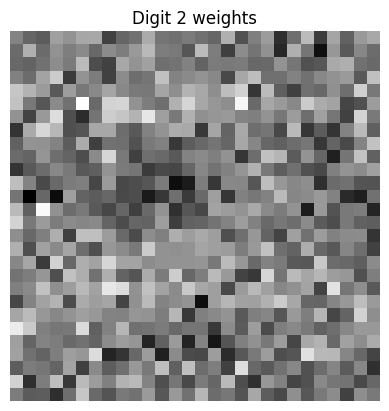

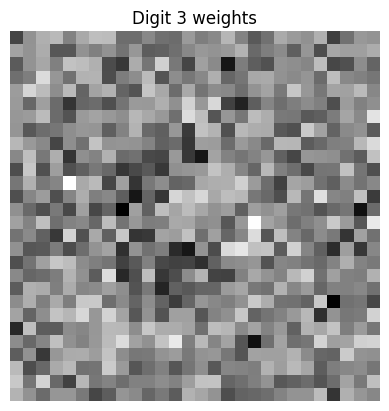

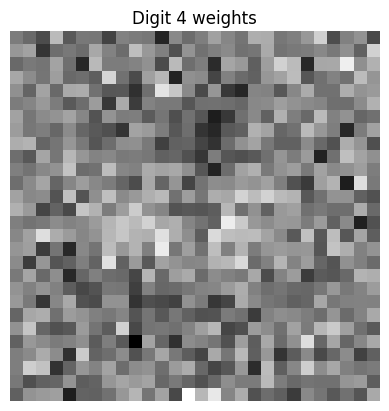

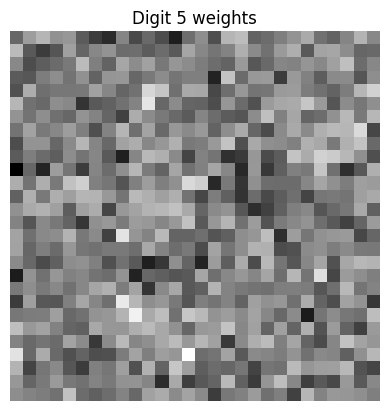

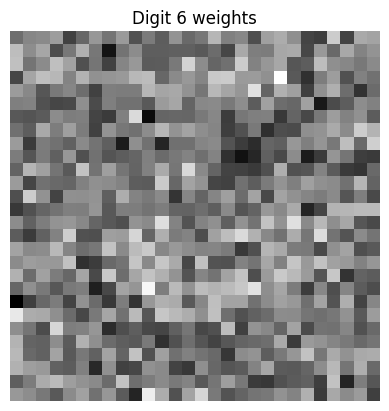

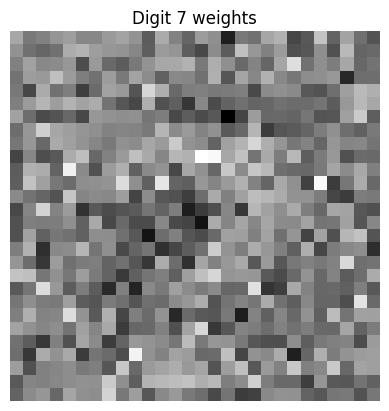

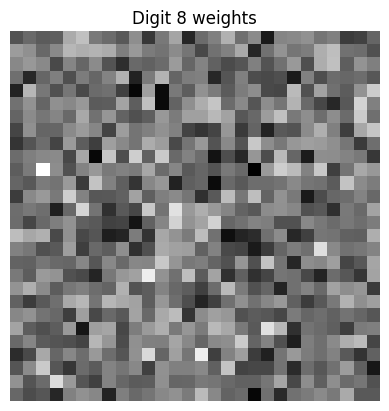

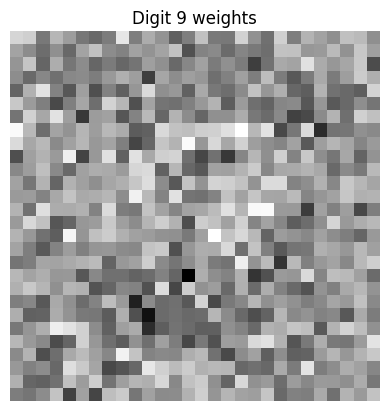

In [ ]:
#
# Show the weights as images.
#

for i in range(10):
  weights = model_W.T[i].reshape(28, 28)

  plt.imshow(weights, cmap='gray')
  plt.title(f"Digit {i} weights")
  plt.axis('off')
  plt.show()


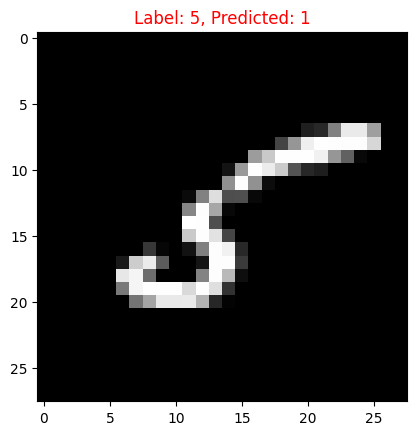

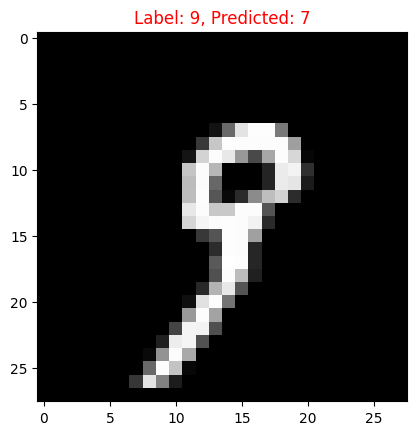

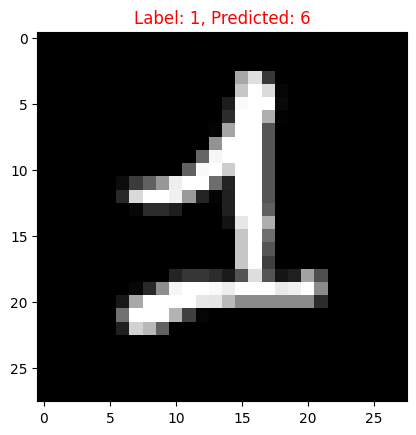

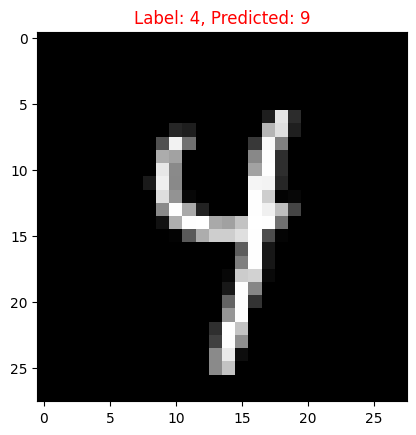

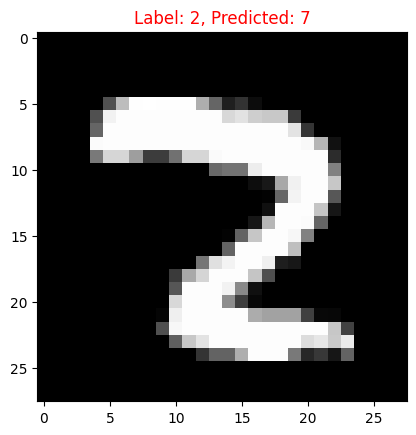

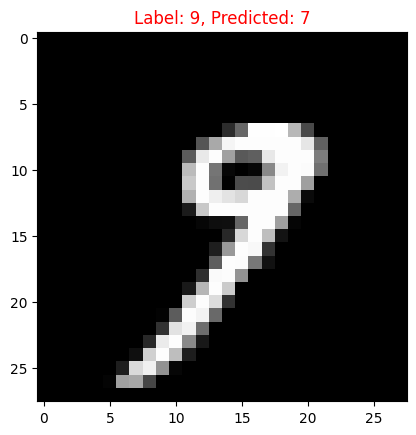

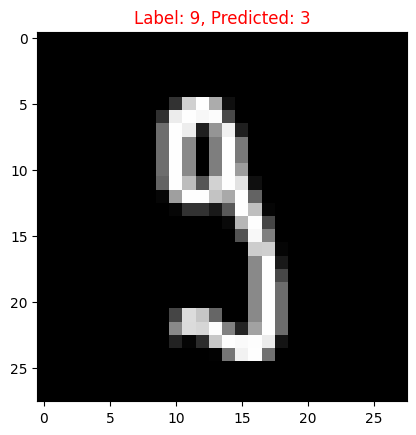

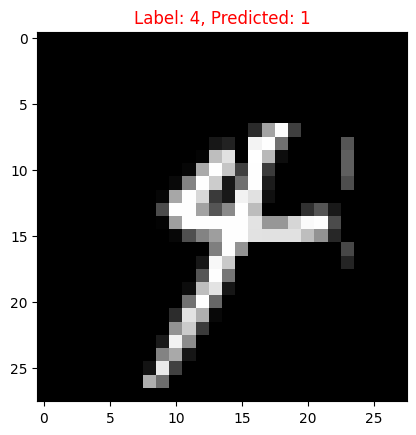

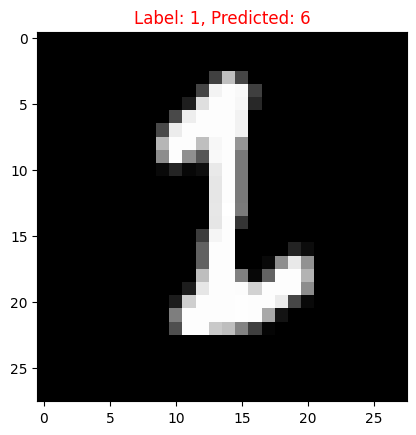

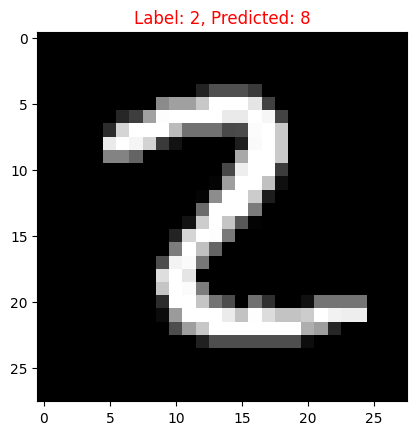

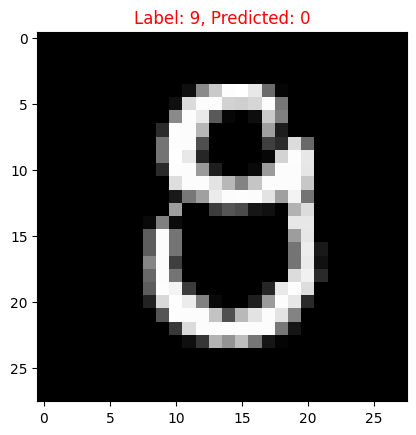

In [ ]:
#
# Test the model and show first 10 samples with predictions.
#

for i in range(100):
  sample = dataset.data[i].float() / 255.0
  sample = torch.reshape(sample, (1, -1))

  logits = sample @ model_W
  predicted_label = torch.argmax(logits).item()
  actual_label = dataset.targets[i].item()

  if predicted_label != actual_label:
    plt.imshow(dataset.data[i], cmap='gray')
    plt.title(f'Label: {actual_label}, Predicted: {predicted_label}')

    title_color = 'green' if actual_label == predicted_label else 'red'
    plt.gca().title.set_color(title_color)

    plt.show()

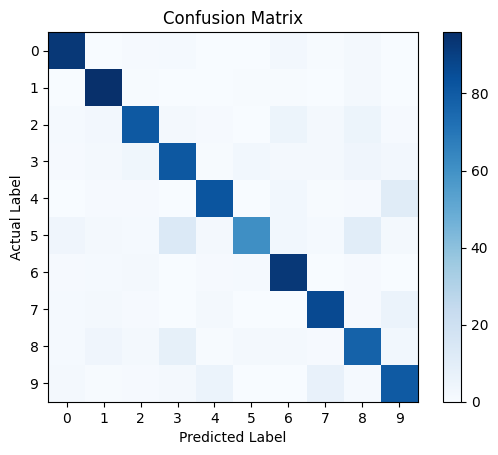

In [ ]:
#
# Run more tests and show the confusion matrix.
#

counters = [0 for _ in range(10)]
confusion_matrix = [[0 for _ in range(10)] for _ in range(10)]

for i in range(10000):
  sample = dataset.data[i].float() / 255.0
  sample = torch.reshape(sample, (1, -1))

  logits = sample @ model_W
  predicted_label = torch.argmax(logits).item()
  actual_label = dataset.targets[i].item()

  confusion_matrix[actual_label][predicted_label] += 1
  counters[actual_label] += 1

for i in range(10):
  for j in range(10):
    confusion_matrix[i][j] /= 0.01 * counters[i]

plt.imshow(confusion_matrix, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(range(10))   
plt.yticks(range(10))
plt.colorbar()
plt.show()

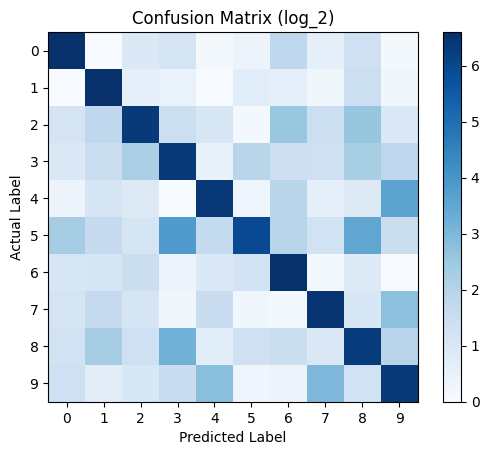

In [ ]:
#
# Use log scale for better visibility of small values in the confusion matrix.
#

confusion_matrix_log = [[0 for _ in range(10)] for _ in range(10)]

for i in range(10):
  for j in range(10):
    confusion_matrix_log[i][j] = log2(confusion_matrix[i][j] + 1) 

plt.imshow(confusion_matrix_log, cmap='Blues')
plt.title('Confusion Matrix (log_2)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(range(10))   
plt.yticks(range(10))
plt.colorbar()
plt.show()